### Imports

In [1]:
import pandas as pd 
import numpy as np
from collections import Counter
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
import nltk
from nltk.corpus import stopwords
import re
import textwrap
import pickle

In [2]:
# nltk.download('stopwords')

In [3]:

# Set seed for reproducibility
np.random.seed(42)

In [4]:
data = pd.read_csv('../data/cleaned_data.csv', sep=',')

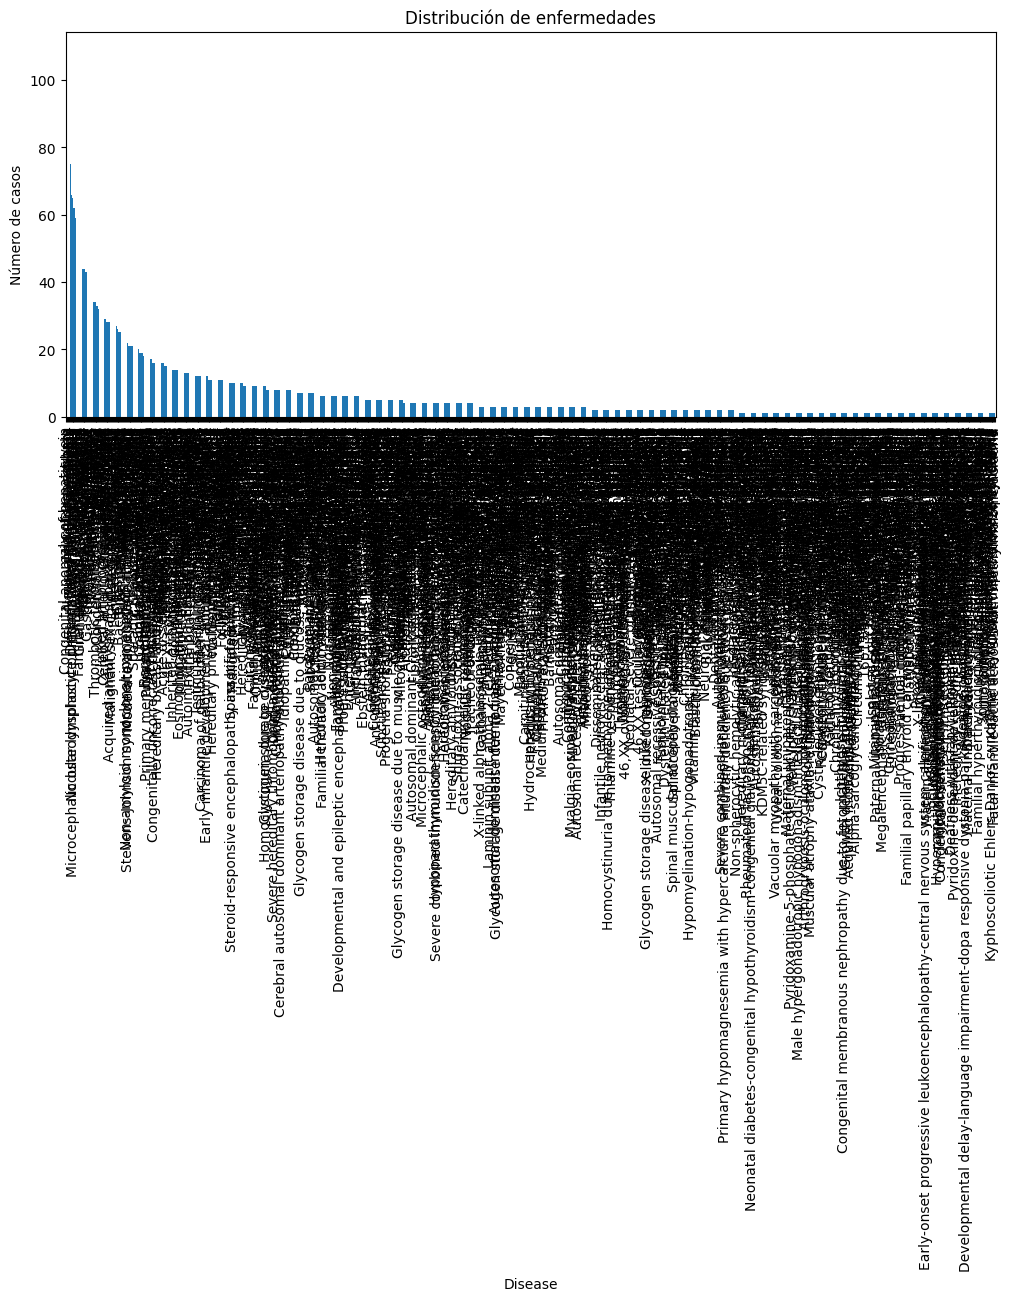

In [5]:
data['Disease'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Distribución de enfermedades")
plt.xlabel("Disease")
plt.ylabel("Número de casos")
plt.show()

In [6]:
data.head()

,CaseSummary,Disease,text_length,Synonyms,category_encoded
0,"At the time of the follow-ups, 1, 2, and 6 mon...",Waldenström macroglobulinemia,221,Not available,975
1,"After transferring to our Center, the parents ...",Cystic fibrosis,1239,CF; Mucoviscidosis,249
2,A woman in her forties visited a local obstetr...,Neurofibromatosis type 1,309,Nonmosaic neurofibromatosis type 1; Von Reckli...,681
3,"Although many cases have been published, it is...",Interatrial communication,658,ASD; Atrial septal defect; Interauricular comm...,492
4,"A 63-year-old man, residing in the Var county ...",Rickettsialpox,1642,Not available,838


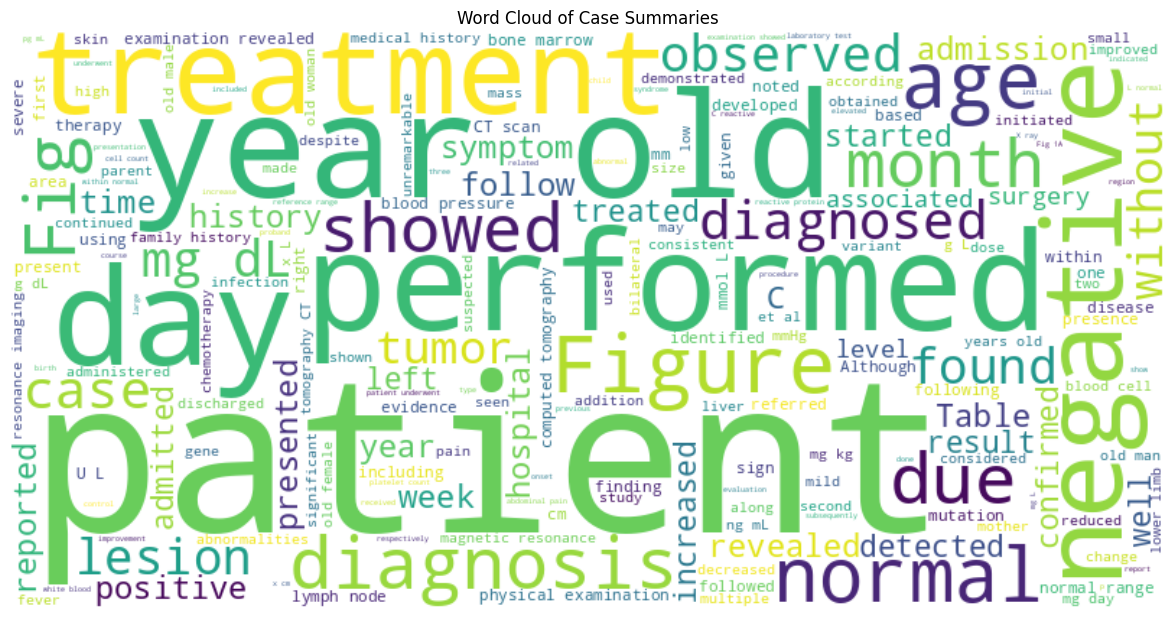

In [7]:
# Create a word cloud for the 'CaseSummary' column
text = ' '.join(data['CaseSummary'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)   
# Display the generated word cloud
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Case Summaries")
plt.show()

#### Data Split

Two splits are generated from the cleaned dataset:

1. **Classification split** (`split_classification.pkl`): Only classes with **≥ 6 samples** are kept, and the split is **stratified** so every class is proportionally represented in both train and test. This is used for notebooks 01 (TF-IDF + LogReg) and 02 (BioLORD + XGBoost).

2. **Retrieval split** (`split_retrieval.pkl`): **All classes** are kept (including singletons) with a standard random split. This is used for retrieval-based experiments (notebooks 03+), where even a single example in train serves as a valid reference for nearest-neighbor search. At evaluation time, test samples whose class is absent from train are excluded.

In [8]:
X = data['CaseSummary']
y = data['category_encoded']

# ── 1. Classification split: stratified, classes with >= 6 samples ──
MIN_SAMPLES_CLF = 6
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES_CLF].index
clf_mask = y.isin(valid_classes)

X_clf = X[clf_mask].reset_index(drop=True)
y_clf = y[clf_mask].reset_index(drop=True)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)

print(f"Classification split (classes >= {MIN_SAMPLES_CLF} samples):")
print(f"  Classes: {y_clf.nunique()}")
print(f"  Train: {len(X_train_clf)}  |  Test: {len(X_test_clf)}")
print(f"  Train classes: {y_train_clf.nunique()}  |  Test classes: {y_test_clf.nunique()}")
print()

# ── 2. Retrieval split: all classes, no stratify ──
X_train_ret, X_test_ret, y_train_ret, y_test_ret = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_test_only = len(set(y_test_ret) - set(y_train_ret))
print(f"Retrieval split (all classes):")
print(f"  Classes: {y.nunique()}")
print(f"  Train: {len(X_train_ret)}  |  Test: {len(X_test_ret)}")
print(f"  Train classes: {y_train_ret.nunique()}  |  Test classes: {y_test_ret.nunique()}")
print(f"  Test-only classes (excluded at eval): {n_test_only}")

Classification split (classes >= 6 samples):
  Classes: 320
  Train: 4312  |  Test: 1079
  Train classes: 320  |  Test classes: 320

Retrieval split (all classes):
  Classes: 1012
  Train: 5532  |  Test: 1383
  Train classes: 942  |  Test classes: 530
  Test-only classes (excluded at eval): 70


In [9]:
print("Classification split shapes:")
print(f"  X_train: {X_train_clf.shape}  y_train: {y_train_clf.shape}")
print(f"  X_test:  {X_test_clf.shape}  y_test:  {y_test_clf.shape}")
print()
print("Retrieval split shapes:")
print(f"  X_train: {X_train_ret.shape}  y_train: {y_train_ret.shape}")
print(f"  X_test:  {X_test_ret.shape}  y_test:  {y_test_ret.shape}")

Classification split shapes:
  X_train: (4312,)  y_train: (4312,)
  X_test:  (1079,)  y_test:  (1079,)

Retrieval split shapes:
  X_train: (5532,)  y_train: (5532,)
  X_test:  (1383,)  y_test:  (1383,)


In [10]:
# Save classification split
with open('../data/split_classification.pkl', 'wb') as f:
    pickle.dump((X_train_clf, X_test_clf, y_train_clf, y_test_clf), f)

# Save retrieval split
with open('../data/split_retrieval.pkl', 'wb') as f:
    pickle.dump((X_train_ret, X_test_ret, y_train_ret, y_test_ret), f)

print("Saved: split_classification.pkl, split_retrieval.pkl")

Saved: split_classification.pkl, split_retrieval.pkl


In [11]:
X_train_clf.head()

3465    In January 2019, a 50-year-old male patient wi...
2436    For instance, Kubota et al described a 43-year...
580     An 8-year-old female (III.1) presented to our ...
307     A 54-year-old female presented with a 10 days ...
2680    Ovarian granulosa cell tumor is an ovarian sex...
Name: CaseSummary, dtype: object

In [12]:
text = X_train_clf.iloc[1]
print(textwrap.fill(text, width=80))

For instance, Kubota et al described a 43-year-old woman presenting with an
cavernous DAVF following transvenous embolization, who subsequently developed a
new DAVF around the jugular valve. A change in hemodynamics was considered the
cause, as venous pressure was elevated and prolonged by the shunted venous flow.
Thus, a transvenous approach for DAVF may result in the formation of a new DAVF.
In addition to treatment for DAVF, treatments for other intracranial vascular
diseases may also cause the formation of new intracranial DAVFs. For instance,
Bai et al in 2012 treated a pediatric case of high-flow pial AVF using
embolization, after which a de novo DAVF and a small arteriovenous malformation
developed as a result of changes in hemodynamics that occurred following the
embolization.


In [13]:
data.duplicated().sum()

np.int64(0)

#### Data preprocessing

In [2]:
# Text preprocessing transformer compatible with scikit-learn pipelines
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        lowercase=True,
        remove_stopwords=False,
        stop_words=None,
        keep_hyphens=True,
        keep_slashes=False,
        preserve_negation=True
    ):
        # Configuration parameters
        self.lowercase = lowercase
        self.remove_stopwords = remove_stopwords
        self.stop_words = stop_words
        self.keep_hyphens = keep_hyphens
        self.keep_slashes = keep_slashes
        self.preserve_negation = preserve_negation

    def fit(self, X, y=None):
        """
        Prepare stopwords set (if enabled).
        This method does not learn from data but prepares internal state.
        """
        if self.remove_stopwords:
            if self.stop_words is None:
                self.stop_words_ = set()
            else:
                self.stop_words_ = set(self.stop_words)

            # Optionally preserve negation words (important in medical/NLP tasks)
            if self.preserve_negation:
                negation_words = {
                    "no", "not", "without", "none", "neither", "nor", "never"
                }
                self.stop_words_ = self.stop_words_ - negation_words
        else:
            self.stop_words_ = set()

        return self

    def _process_text(self, text):
        """
        Apply full preprocessing pipeline to a single text string.
        """
        # Handle None values safely
        text = "" if text is None else str(text)

        # Convert to lowercase if enabled
        if self.lowercase:
            text = text.lower()

        # Normalize whitespace characters (newlines, tabs → space)
        text = re.sub(r"[\r\n\t]+", " ", text)

        # Build allowed character pattern dynamically
        allowed = "a-z0-9\\s"
        if self.keep_hyphens:
            allowed += r"\-"
        if self.keep_slashes:
            allowed += r"/"

        # Remove all characters NOT in the allowed set
        text = re.sub(fr"[^{allowed}]", " ", text)

        # Normalize hyphen spacing:
        # Convert "anti - nmda" → "anti-nmda"
        text = re.sub(r"\s*-\s*", "-", text)

        # Collapse multiple spaces into one and strip leading/trailing spaces
        text = re.sub(r"\s+", " ", text).strip()

        # Tokenize by whitespace
        tokens = text.split()

        # Remove stopwords if enabled
        if self.remove_stopwords and self.stop_words_:
            tokens = [w for w in tokens if w not in self.stop_words_]

        # Return cleaned text as a single string
        return " ".join(tokens)

    def transform(self, X):
        """
        Apply preprocessing to a pandas Series or iterable of texts.
        """
        if hasattr(X, "apply"):   # If X is a pandas Series
            return X.apply(self._process_text)

        # Otherwise convert to pandas Series for consistency
        return pd.Series(X).apply(self._process_text)

#### Preprocessing data Pipeline

In [15]:
steps = [
    ("preprocessor", TextPreprocessor()),
    ("vectorizer", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        )),
    ("clf", LogisticRegression(
        solver='saga',
        max_iter=2000,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1))
]

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    Pipeline(steps),
    X_train_clf,
    y_train_clf,
    cv=cv,
    scoring="f1_macro",
    verbose=2,
    n_jobs=1
)

[CV] END .................................................... total time=  48.6s
[CV] END .................................................... total time=  48.9s
[CV] END .................................................... total time=  44.5s
[CV] END .................................................... total time= 3.5min
[CV] END .................................................... total time= 1.9min


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  7.7min finished


In [17]:
print("CV scores:", scores)
print("Mean CV f1_macro:", scores.mean())
print("Std CV f1_macro:", scores.std())

CV scores: [0.26270401 0.27619125 0.27446747 0.24901359 0.25588482]
Mean CV f1_macro: 0.2636522275883731
Std CV f1_macro: 0.010485398405232174


#### Fit the model on the full training set

In [18]:
model = Pipeline(steps)
model.fit(X_train_clf, y_train_clf)

,steps,"[('preprocessor', ...), ('vectorizer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,lowercase,True
,remove_stopwords,False
,stop_words,None
,keep_hyphens,True
,keep_slashes,False
,preserve_negation,True
,input,'content'


#### Evaluate on the test set

In [19]:
from sklearn.metrics import f1_score

y_pred = model.predict(X_test_clf)

print(f"Test Accuracy:  {accuracy_score(y_test_clf, y_pred):.4f}")
print(f"Test F1 (macro):    {f1_score(y_test_clf, y_pred, average='macro', zero_division=0):.4f}")
print(f"Test F1 (weighted): {f1_score(y_test_clf, y_pred, average='weighted', zero_division=0):.4f}")
print()
print(classification_report(y_test_clf, y_pred, zero_division=0))

Test Accuracy:  0.3160
Test F1 (macro):    0.2909
Test F1 (weighted): 0.3057

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
          10       0.50      0.33      0.40         3
          14       0.29      0.33      0.31         6
          16       0.00      0.00      0.00         4
          24       0.40      0.67      0.50         6
          29       0.20      0.50      0.29         2
          33       0.00      0.00      0.00         3
          35       0.33      0.33      0.33         3
          36       0.67      0.33      0.44         6
          43       0.25      0.67      0.36         3
          46       0.00      0.00      0.00         2
          47       0.00      0.00      0.00         1
          48       0.25      0.33      0.29         3
          55       0.20      1.00      0.33         1
          59       0.00      0.00      0.00         1
          61       0.00      0.00      0.00         3
   

In [20]:
print(type(y_train_clf))
print(y_train_clf.shape)
print(y_train_clf.head())

<class 'pandas.core.series.Series'>
(4312,)
3465    331
2436    289
580     681
307     828
2680    581
Name: category_encoded, dtype: int64


## Summary

### What was done
- **Dataset**: Loaded a cleaned dataset of clinical case summaries mapped to rare disease categories (~6,915 samples across ~1,012 disease classes).
- **Data splits**: Generated two separate train/test splits (80/20):
  1. **Classification split** (stratified, classes ≥ 6 samples): ensures every class is represented in both train and test. Used for classification experiments (TF-IDF + LogReg, BioLORD + XGBoost).
  2. **Retrieval split** (all classes, no stratification): preserves the full disease catalog for nearest-neighbor retrieval. Test-only classes are filtered at evaluation time.
- **EDA**: Visualized disease distribution (highly imbalanced, many classes with very few samples) and generated a word cloud of case summaries to inspect dominant vocabulary.
- **Text preprocessing**: Built a custom sklearn-compatible `TextPreprocessor` that lowercases text, removes special characters while preserving hyphens (important for medical terms like "anti-NMDA", "IL-6"), and optionally strips stopwords while keeping negation words ("no", "not", "without") which carry clinical significance.
- **Feature extraction**: Applied TF-IDF vectorization with unigrams + bigrams (`ngram_range=(1,2)`), sublinear term frequency scaling (`sublinear_tf=True`), and frequency filters (`min_df=2`, `max_df=0.95`).
- **Model**: Trained a Logistic Regression classifier (`solver='saga'`, `class_weight='balanced'`, `max_iter=2000`) within an sklearn `Pipeline` using the classification split.
- **Evaluation**: Performed 5-fold stratified cross-validation and evaluated on the held-out test set.

### Results
(To be updated after re-running with the corrected classification split)

### Conclusions
- The TF-IDF + Logistic Regression baseline is expected to yield low performance given the multi-class setting with limited examples per class.
- The stratified classification split ensures fair evaluation — every class has representation in both train and test.
- The separate retrieval split preserves all 1,012 classes (including singletons) for nearest-neighbor experiments where even a single reference example is valuable.

### Next Steps
- Re-run notebook 02 (BioLORD + XGBoost) with the classification split.
- Re-run notebook 03 (retrieval benchmark) with the retrieval split.
- Test additional embedding models (MedCPT, e5-large-v2) for retrieval in new notebooks.